In [ ]:
from post_process_src import post_process_src

post_process_src.stages.walls.run_walls()

In [9]:
import pickle

# Deserialize (load) the object
with open('wall_output.pickle', 'rb') as f:
    wall_output_dict = pickle.load(f)

In [ ]:
wall_output_dict['walls']

[{'id': '1',
  'levelIndex': 0,
  'zRange': {'min': 2.49360630011022, 'max': 13.312132247549885},
  'footprint': [{'x': 73.87933426877211, 'y': 154.90910440107382},
   {'x': 73.87933426877211, 'y': 154.90910440107382},
   {'x': 73.87933426877211, 'y': 154.90910440107382},
   {'x': 74.07941645607053, 'y': 154.8600124922744},
   {'x': 74.20976573742969, 'y': 155.39127253012873},
   {'x': 74.20976573742969, 'y': 155.39127253012873},
   {'x': 74.20976573742969, 'y': 155.39127253012873},
   {'x': 74.4098479247281, 'y': 155.34218062132933},
   {'x': 74.4098479247281, 'y': 155.34218062132933},
   {'x': 74.4098479247281, 'y': 155.34218062132933},
   {'x': 74.60993011202653, 'y': 155.2930887125299},
   {'x': 74.60993011202653, 'y': 155.2930887125299},
   {'x': 74.81001229932494, 'y': 155.2439968037305},
   {'x': 80.41231354368063, 'y': 153.86942335734702},
   {'x': 96.418888527554, 'y': 149.94207065339424},
   {'x': 96.418888527554, 'y': 149.94207065339424},
   {'x': 96.61897071485241, 'y': 149

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def _get_walls(wall_output_dict_or_wall_lst):
    """
    Accept either:
      - wall_output_dict = {"points": ..., "walls": wall_lst}
      - wall_lst directly
    """
    if isinstance(wall_output_dict_or_wall_lst, dict):
        return wall_output_dict_or_wall_lst["walls"]
    return wall_output_dict_or_wall_lst


def _footprint_to_array(wall):
    return np.array(
        [[p["x"], p["y"]] for p in wall["footprint"]],
        dtype=float
    )


def plot_wall_footprints_2d(
    wall_output_dict_or_wall_lst,
    level=None,
    show_ids=True,
    figsize=(10, 10),
):
    """
    Top-down 2D visualization of wall footprints.
    """

    walls = _get_walls(wall_output_dict_or_wall_lst)

    if level is not None:
        walls = [w for w in walls if w.get("levelIndex") == level]

    fig, ax = plt.subplots(figsize=figsize)

    for wall in walls:
        fp = _footprint_to_array(wall)

        if len(fp) == 0:
            continue

        # Close polygon for plotting
        fp_closed = np.vstack([fp, fp[0]])

        ax.plot(fp_closed[:, 0], fp_closed[:, 1], linewidth=2)
        ax.fill(fp[:, 0], fp[:, 1], alpha=0.25)

        if show_ids:
            cx, cy = fp.mean(axis=0)
            ax.text(cx, cy, str(wall["id"]), fontsize=9)

    title = "Wall Footprints"
    if level is not None:
        title += f" - Level {level}"

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True)

    plt.show()

def _set_axes_equal_3d(ax):
    """
    Make 3D axes have equal scale so walls are not visually distorted.
    """
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])

    max_range = max(x_range, y_range, z_range)

    x_mid = np.mean(x_limits)
    y_mid = np.mean(y_limits)
    z_mid = np.mean(z_limits)

    ax.set_xlim3d([x_mid - max_range / 2, x_mid + max_range / 2])
    ax.set_ylim3d([y_mid - max_range / 2, y_mid + max_range / 2])
    ax.set_zlim3d([z_mid - max_range / 2, z_mid + max_range / 2])


def plot_walls_3d(
    wall_output_dict_or_wall_lst,
    level=None,
    show_ids=True,
    figsize=(12, 10),
):
    """
    3D visualization by extruding each wall footprint from zRange.min to zRange.max.
    """

    walls = _get_walls(wall_output_dict_or_wall_lst)

    if level is not None:
        walls = [w for w in walls if w.get("levelIndex") == level]

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")

    all_xyz = []

    for wall in walls:
        fp = _footprint_to_array(wall)

        if len(fp) < 2:
            continue

        z_min = float(wall["zRange"]["min"])
        z_max = float(wall["zRange"]["max"])

        bottom = [(x, y, z_min) for x, y in fp]
        top = [(x, y, z_max) for x, y in fp]

        faces = []

        # Bottom and top faces
        faces.append(bottom)
        faces.append(top)

        # Side faces
        n = len(fp)
        for i in range(n):
            j = (i + 1) % n
            face = [
                bottom[i],
                bottom[j],
                top[j],
                top[i],
            ]
            faces.append(face)

        poly = Poly3DCollection(faces, alpha=0.3, linewidths=1)
        ax.add_collection3d(poly)

        # Draw edges
        bottom_closed = bottom + [bottom[0]]
        top_closed = top + [top[0]]

        ax.plot(
            [p[0] for p in bottom_closed],
            [p[1] for p in bottom_closed],
            [p[2] for p in bottom_closed],
        )

        ax.plot(
            [p[0] for p in top_closed],
            [p[1] for p in top_closed],
            [p[2] for p in top_closed],
        )

        for b, t in zip(bottom, top):
            ax.plot(
                [b[0], t[0]],
                [b[1], t[1]],
                [b[2], t[2]],
            )

        if show_ids:
            cx, cy = fp.mean(axis=0)
            cz = (z_min + z_max) / 2
            ax.text(cx, cy, cz, str(wall["id"]), fontsize=8)

        all_xyz.extend(bottom)
        all_xyz.extend(top)

    if all_xyz:
        all_xyz = np.array(all_xyz)
        ax.set_xlim(all_xyz[:, 0].min(), all_xyz[:, 0].max())
        ax.set_ylim(all_xyz[:, 1].min(), all_xyz[:, 1].max())
        ax.set_zlim(all_xyz[:, 2].min(), all_xyz[:, 2].max())
        _set_axes_equal_3d(ax)

    title = "3D Wall Visualization"
    if level is not None:
        title += f" - Level {level}"

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    plt.show()

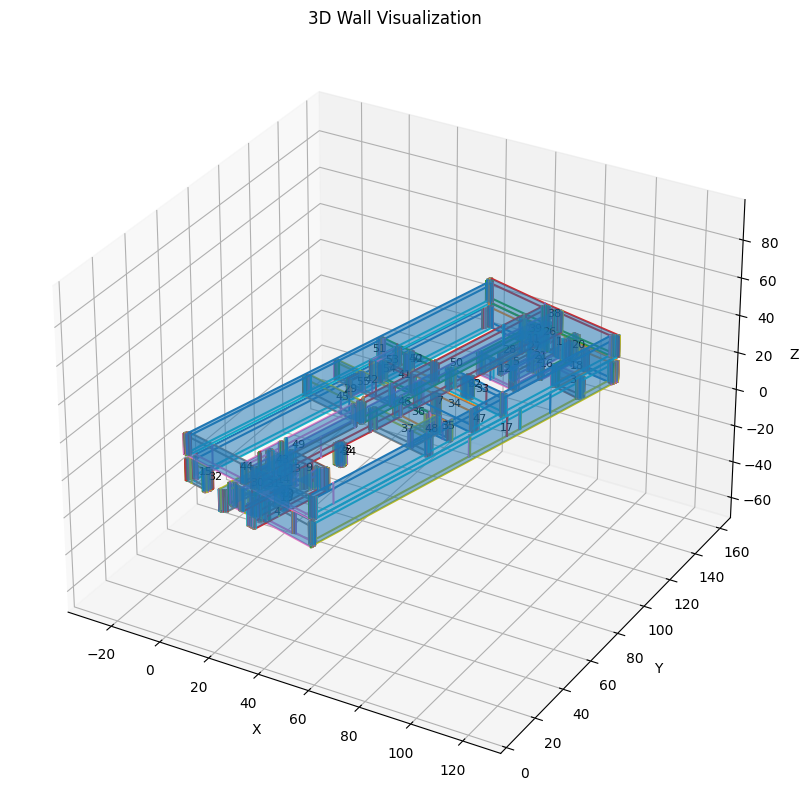

In [10]:
plot_walls_3d(wall_output_dict)

In [16]:
import numpy as np
import plotly.graph_objects as go


def export_single_wall_points_html(
    wall_output_dict,
    wall_id=17,
    output_html="wall_17_points.html",
    point_size=2,
    show_bbox=True,
    show_footprint=True,
    show_wall_surface=True,
):
    wall_id = str(wall_id)

    # -------------------------
    # Find wall metadata
    # -------------------------
    wall = None
    for w in wall_output_dict["walls"]:
        if str(w["id"]) == wall_id:
            wall = w
            break

    if wall is None:
        raise ValueError(f"Wall id {wall_id} not found in wall_output_dict['walls'].")

    # -------------------------
    # Get points belonging to this wall
    # -------------------------
    wall_points = []

    for p in wall_output_dict["points"]:
        if p.get("category") == "wall" and str(p.get("id")) == wall_id:
            loc = p["location"]
            color = p.get("color", {"r": 80, "g": 80, "b": 80})

            wall_points.append(
                [
                    float(loc["x"]),
                    float(loc["y"]),
                    float(loc["z"]),
                    int(color["r"]),
                    int(color["g"]),
                    int(color["b"]),
                ]
            )

    if len(wall_points) == 0:
        raise ValueError(f"No points found for wall id {wall_id} in wall_output_dict['points'].")

    wall_points = np.array(wall_points, dtype=float)

    xyz = wall_points[:, :3]
    rgb = wall_points[:, 3:6].astype(int)

    point_colors = [
        f"rgb({r},{g},{b})"
        for r, g, b in rgb
    ]

    fig = go.Figure()

    # -------------------------
    # Plot actual wall points
    # -------------------------
    fig.add_trace(
        go.Scatter3d(
            x=xyz[:, 0],
            y=xyz[:, 1],
            z=xyz[:, 2],
            mode="markers",
            marker=dict(
                size=point_size,
                color=point_colors,
                opacity=0.9,
            ),
            name=f"wall {wall_id} points",
        )
    )

    # -------------------------
    # Plot bbox from wall['bbox']
    # -------------------------
    if show_bbox and "bbox" in wall:
        bbox = np.array(
            [[p["x"], p["y"], p["z"]] for p in wall["bbox"]],
            dtype=float,
        )

        if len(bbox) > 0:
            bbox_closed = np.vstack([bbox, bbox[0]])

            fig.add_trace(
                go.Scatter3d(
                    x=bbox_closed[:, 0],
                    y=bbox_closed[:, 1],
                    z=bbox_closed[:, 2],
                    mode="lines+markers+text",
                    marker=dict(size=5),
                    line=dict(width=6),
                    text=[f"bbox {i}" for i in range(len(bbox))] + ["bbox 0"],
                    textposition="top center",
                    name="bbox",
                )
            )

    # -------------------------
    # Plot footprint polygon at z_min and z_max
    # -------------------------
    footprint_xy = np.array(
        [[p["x"], p["y"]] for p in wall["footprint"]],
        dtype=float,
    )

    z_min = float(wall["zRange"]["min"])
    z_max = float(wall["zRange"]["max"])

    footprint_bottom = np.column_stack(
        [
            footprint_xy[:, 0],
            footprint_xy[:, 1],
            np.full(len(footprint_xy), z_min),
        ]
    )

    footprint_top = np.column_stack(
        [
            footprint_xy[:, 0],
            footprint_xy[:, 1],
            np.full(len(footprint_xy), z_max),
        ]
    )

    if show_footprint:
        fp_bottom_closed = np.vstack([footprint_bottom, footprint_bottom[0]])
        fp_top_closed = np.vstack([footprint_top, footprint_top[0]])

        fig.add_trace(
            go.Scatter3d(
                x=fp_bottom_closed[:, 0],
                y=fp_bottom_closed[:, 1],
                z=fp_bottom_closed[:, 2],
                mode="lines+markers",
                line=dict(width=5),
                marker=dict(size=4),
                name="footprint at z_min",
            )
        )

        fig.add_trace(
            go.Scatter3d(
                x=fp_top_closed[:, 0],
                y=fp_top_closed[:, 1],
                z=fp_top_closed[:, 2],
                mode="lines+markers",
                line=dict(width=5, dash="dash"),
                marker=dict(size=4),
                name="footprint at z_max",
            )
        )

        # vertical edges between bottom and top footprint
        for i in range(len(footprint_bottom)):
            b = footprint_bottom[i]
            t = footprint_top[i]

            fig.add_trace(
                go.Scatter3d(
                    x=[b[0], t[0]],
                    y=[b[1], t[1]],
                    z=[b[2], t[2]],
                    mode="lines",
                    line=dict(width=3),
                    showlegend=False,
                )
            )

    # -------------------------
    # Optional transparent wall surface from footprint
    # -------------------------
    if show_wall_surface:
        vertices = np.vstack([footprint_bottom, footprint_top])
        n = len(footprint_bottom)

        i_faces = []
        j_faces = []
        k_faces = []

        # side faces: two triangles per side
        for idx in range(n):
            next_idx = (idx + 1) % n

            bottom_0 = idx
            bottom_1 = next_idx
            top_0 = idx + n
            top_1 = next_idx + n

            i_faces.append(bottom_0)
            j_faces.append(bottom_1)
            k_faces.append(top_1)

            i_faces.append(bottom_0)
            j_faces.append(top_1)
            k_faces.append(top_0)

        fig.add_trace(
            go.Mesh3d(
                x=vertices[:, 0],
                y=vertices[:, 1],
                z=vertices[:, 2],
                i=i_faces,
                j=j_faces,
                k=k_faces,
                opacity=0.15,
                color="lightblue",
                name="wall surface",
                showscale=False,
            )
        )

    # -------------------------
    # Equal-ish 3D scale
    # -------------------------
    all_xyz = xyz

    if show_bbox and "bbox" in wall and len(wall["bbox"]) > 0:
        all_xyz = np.vstack([all_xyz, bbox])

    all_xyz = np.vstack([all_xyz, footprint_bottom, footprint_top])

    mins = all_xyz.min(axis=0)
    maxs = all_xyz.max(axis=0)
    centers = (mins + maxs) / 2
    ranges = maxs - mins
    max_range = ranges.max()

    padding = max_range * 0.05

    x_range = [
        centers[0] - max_range / 2 - padding,
        centers[0] + max_range / 2 + padding,
    ]
    y_range = [
        centers[1] - max_range / 2 - padding,
        centers[1] + max_range / 2 + padding,
    ]
    z_range = [
        centers[2] - max_range / 2 - padding,
        centers[2] + max_range / 2 + padding,
    ]

    fig.update_layout(
        title=f"Wall {wall_id}: points inside footprint polygon",
        scene=dict(
            xaxis=dict(title="X", range=x_range),
            yaxis=dict(title="Y", range=y_range),
            zaxis=dict(title="Z", range=z_range),
            aspectmode="cube",
        ),
        legend=dict(itemsizing="constant"),
        margin=dict(l=0, r=0, t=40, b=0),
    )

    fig.write_html(output_html, include_plotlyjs="cdn")
    print(f"Saved HTML to: {output_html}")

    return fig

In [17]:
fig = export_single_wall_points_html(
    wall_output_dict,
    wall_id=17,
    output_html="wall_17_points.html",
)

fig.show()

Saved HTML to: wall_17_points.html


In [18]:
import numpy as np
import matplotlib.pyplot as plt


def get_wall_by_id(wall_output_dict, wall_id):
    wall_id = str(wall_id)
    for wall in wall_output_dict["walls"]:
        if str(wall["id"]) == wall_id:
            return wall
    raise ValueError(f"Wall id {wall_id} not found.")


def get_wall_points_by_id(wall_output_dict, wall_id):
    wall_id = str(wall_id)
    pts = []

    for p in wall_output_dict["points"]:
        if p.get("category") == "wall" and str(p.get("id")) == wall_id:
            loc = p["location"]
            pts.append([loc["x"], loc["y"], loc["z"]])

    if len(pts) == 0:
        raise ValueError(f"No wall points found for wall id {wall_id}.")

    return np.array(pts, dtype=float)


def get_wall_length_axis_from_footprint(wall):
    """
    Use the longest edge of the footprint polygon as the wall length direction.
    """
    footprint = np.array(
        [[p["x"], p["y"]] for p in wall["footprint"]],
        dtype=float
    )

    max_len = -1
    best_axis = None

    n = len(footprint)
    for i in range(n):
        p0 = footprint[i]
        p1 = footprint[(i + 1) % n]
        edge = p1 - p0
        length = np.linalg.norm(edge)

        if length > max_len:
            max_len = length
            best_axis = edge / length

    return best_axis


def project_wall_points_to_length_z(wall_output_dict, wall_id=17):
    wall = get_wall_by_id(wall_output_dict, wall_id)
    pts = get_wall_points_by_id(wall_output_dict, wall_id)

    xyz = pts[:, :3]
    xy = xyz[:, :2]
    z = xyz[:, 2]

    axis = get_wall_length_axis_from_footprint(wall)

    footprint_xy = np.array(
        [[p["x"], p["y"]] for p in wall["footprint"]],
        dtype=float
    )

    # Use footprint projection range as the wall length range
    fp_proj = footprint_xy @ axis
    s_min = fp_proj.min()
    s_max = fp_proj.max()

    # Project point xy onto wall length axis
    s = xy @ axis

    # Shift so wall starts from 0
    s = s - s_min

    wall_length = s_max - s_min

    z_min = float(wall["zRange"]["min"])
    z_max = float(wall["zRange"]["max"])

    return s, z, wall_length, z_min, z_max

In [19]:
def plot_wall_opening_histogram(
    wall_output_dict,
    wall_id=17,
    length_bin_size=0.05,
    z_bin_size=0.05,
    save_path=None,
):
    """
    Creates a 2D histogram image:
        x axis = wall length direction
        y axis = z height
        value = point density

    length_bin_size and z_bin_size are in your scene units.
    For meters, 0.05 means 5 cm bins.
    """

    s, z, wall_length, z_min, z_max = project_wall_points_to_length_z(
        wall_output_dict,
        wall_id=wall_id,
    )

    num_length_bins = max(10, int(np.ceil(wall_length / length_bin_size)))
    num_z_bins = max(10, int(np.ceil((z_max - z_min) / z_bin_size)))

    H, s_edges, z_edges = np.histogram2d(
        s,
        z,
        bins=[num_length_bins, num_z_bins],
        range=[
            [0, wall_length],
            [z_min, z_max],
        ],
    )

    # H shape is [length_bins, z_bins]
    # For image display, transpose so x=length, y=z
    H_img = H.T

    plt.figure(figsize=(12, 5))
    plt.imshow(
        H_img,
        origin="lower",
        aspect="auto",
        extent=[0, wall_length, z_min, z_max],
        cmap="gray_r",
    )

    plt.colorbar(label="point count")
    plt.xlabel("Wall length direction")
    plt.ylabel("Z height")
    plt.title(f"Wall {wall_id}: length-z point histogram")

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

    return H_img, s_edges, z_edges

C:\Users\cwei\AppData\Local\Temp\ipykernel_44024\2257606853.py:49: RuntimeWarning:

invalid value encountered in divide



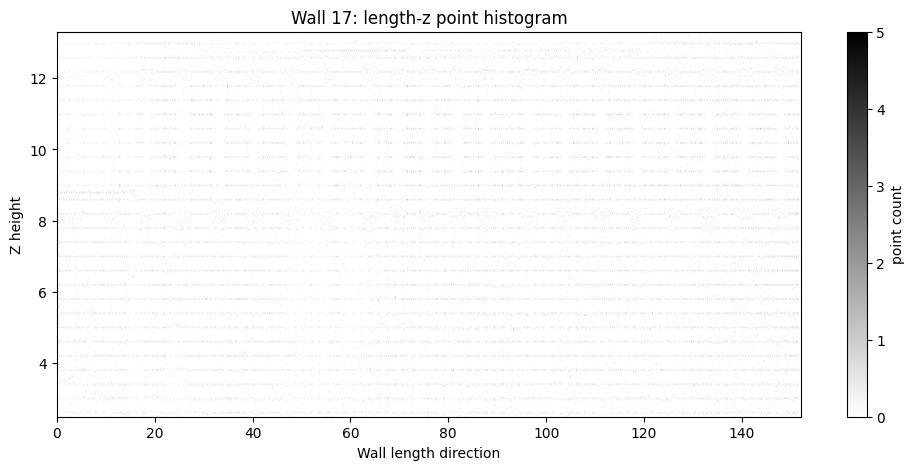

In [20]:
H_img, s_edges, z_edges = plot_wall_opening_histogram(
    wall_output_dict,
    wall_id=17,
    length_bin_size=0.05,
    z_bin_size=0.05,
    save_path="wall_17_length_z_histogram.png",
)

In [ ]:
from json_output_visualization import (
    create_e57_wall_length_z_image,
    plot_e57_wall_length_z_image,
)

e57_result = create_e57_wall_length_z_image(
    "wall_output.pickle",
    "LaramieCM.e57",
    wall_id=17,
    length_bin_size=0.05,
    z_bin_size=0.05,
    count_threshold=10,  # dense E57 needs higher threshold than sparse CSV
    margin_m=0.25,
)

fig = plot_e57_wall_length_z_image(
    e57_result,
    wall_id=17,
    save_path="wall_17_e57_length_z_image_bbox.png",
)

TypeError: unsupported operand type(s) for |: 'types.GenericAlias' and 'NoneType'

In [39]:
import numpy as np
import matplotlib.pyplot as plt


def get_wall_by_id(wall_output_dict, wall_id):
    wall_id = str(wall_id)
    for wall in wall_output_dict["walls"]:
        if str(wall["id"]) == wall_id:
            return wall
    raise ValueError(f"Wall id {wall_id} not found.")


def get_wall_points_with_rgb(wall_output_dict, wall_id):
    wall_id = str(wall_id)

    pts = []
    rgb = []

    for p in wall_output_dict["points"]:
        if p.get("category") == "wall" and str(p.get("id")) == wall_id:
            loc = p["location"]
            color = p.get("color", {"r": 128, "g": 128, "b": 128})

            pts.append([
                float(loc["x"]),
                float(loc["y"]),
                float(loc["z"]),
            ])

            rgb.append([
                int(color["r"]),
                int(color["g"]),
                int(color["b"]),
            ])

    if len(pts) == 0:
        raise ValueError(f"No points found for wall id {wall_id}.")

    return np.array(pts, dtype=float), np.array(rgb, dtype=float)


def get_wall_length_axis_from_footprint(wall):
    footprint = np.array(
        [[p["x"], p["y"]] for p in wall["footprint"]],
        dtype=float,
    )

    max_len = -1
    best_axis = None

    n = len(footprint)

    for i in range(n):
        p0 = footprint[i]
        p1 = footprint[(i + 1) % n]

        edge = p1 - p0
        length = np.linalg.norm(edge)

        if length > max_len:
            max_len = length
            best_axis = edge / length

    return best_axis


def project_wall_points_to_length_z_with_rgb(
    wall_output_dict,
    wall_id=17,
    z_crop=None,
):
    wall = get_wall_by_id(wall_output_dict, wall_id)
    pts, rgb = get_wall_points_with_rgb(wall_output_dict, wall_id)

    xyz = pts[:, :3]
    xy = xyz[:, :2]
    z = xyz[:, 2]

    axis = get_wall_length_axis_from_footprint(wall)

    footprint_xy = np.array(
        [[p["x"], p["y"]] for p in wall["footprint"]],
        dtype=float,
    )

    fp_proj = footprint_xy @ axis
    s_min = fp_proj.min()
    s_max = fp_proj.max()

    s = xy @ axis
    s = s - s_min

    wall_length = s_max - s_min

    z_min = float(wall["zRange"]["min"])
    z_max = float(wall["zRange"]["max"])

    if z_crop is not None:
        z_min, z_max = z_crop
        keep = (z >= z_min) & (z <= z_max)
        s = s[keep]
        z = z[keep]
        rgb = rgb[keep]

    keep = (s >= 0) & (s <= wall_length)
    s = s[keep]
    z = z[keep]
    rgb = rgb[keep]

    return s, z, rgb, wall_length, z_min, z_max

In [40]:
def create_wall_binary_image(
    wall_output_dict,
    wall_id=17,
    length_bin_size=1.0,
    z_bin_size=0.25,
    count_threshold=1,
    z_crop=None,
):
    """
    Create a 2D binary image from wall points.

    binary_img[y, x] = 1 means occupied wall cell
    binary_img[y, x] = 0 means empty / possible opening cell

    x axis = wall length direction
    y axis = z height
    """

    s, z, rgb, wall_length, z_min, z_max = project_wall_points_to_length_z_with_rgb(
        wall_output_dict,
        wall_id=wall_id,
        z_crop=z_crop,
    )

    n_length = max(5, int(np.ceil(wall_length / length_bin_size)))
    n_z = max(5, int(np.ceil((z_max - z_min) / z_bin_size)))

    count_img = np.zeros((n_z, n_length), dtype=np.float32)
    rgb_sum_img = np.zeros((n_z, n_length, 3), dtype=np.float32)

    x_idx = np.floor(s / wall_length * n_length).astype(int)
    y_idx = np.floor((z - z_min) / (z_max - z_min) * n_z).astype(int)

    x_idx = np.clip(x_idx, 0, n_length - 1)
    y_idx = np.clip(y_idx, 0, n_z - 1)

    for x, y, c in zip(x_idx, y_idx, rgb):
        count_img[y, x] += 1
        rgb_sum_img[y, x] += c

    binary_img = count_img >= count_threshold

    avg_rgb_img = np.zeros_like(rgb_sum_img)
    valid = count_img > 0
    avg_rgb_img[valid] = rgb_sum_img[valid] / count_img[valid, None]

    # RGB grayscale proxy. If you have real reflectivity/intensity, use that instead.
    reflectivity_img = (
        0.299 * avg_rgb_img[:, :, 0]
        + 0.587 * avg_rgb_img[:, :, 1]
        + 0.114 * avg_rgb_img[:, :, 2]
    )

    s_edges = np.linspace(0, wall_length, n_length + 1)
    z_edges = np.linspace(z_min, z_max, n_z + 1)

    return {
        "count_img": count_img,
        "binary_img": binary_img,
        "avg_rgb_img": avg_rgb_img,
        "reflectivity_img": reflectivity_img,
        "s_edges": s_edges,
        "z_edges": z_edges,
        "wall_length": wall_length,
        "z_min": z_min,
        "z_max": z_max,
    }

In [42]:
def plot_wall_binary_image_result(
    result,
    wall_id=17,
    save_path="wall_17_binary_image.png",
):
    count_img = result["count_img"]
    binary_img = result["binary_img"]
    reflectivity_img = result["reflectivity_img"]
    s_edges = result["s_edges"]
    z_edges = result["z_edges"]

    wall_length = s_edges[-1]
    z_min = z_edges[0]
    z_max = z_edges[-1]

    fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

    im0 = axes[0].imshow(
        count_img,
        origin="lower",
        aspect="auto",
        extent=[0, wall_length, z_min, z_max],
        cmap="gray_r",
    )
    axes[0].set_title("Point count per cell")
    plt.colorbar(im0, ax=axes[0], label="point count")

    axes[1].imshow(
        binary_img.astype(float),
        origin="lower",
        aspect="auto",
        extent=[0, wall_length, z_min, z_max],
        cmap="gray_r",
        vmin=0,
        vmax=1,
    )
    axes[1].set_title("Binary image: 1 = wall, 0 = empty/opening")

    im2 = axes[2].imshow(
        reflectivity_img,
        origin="lower",
        aspect="auto",
        extent=[0, wall_length, z_min, z_max],
        cmap="gray",
    )
    axes[2].set_title("Average RGB brightness per cell")
    plt.colorbar(im2, ax=axes[2], label="avg brightness")

    for ax in axes:
        ax.set_xlabel("Wall length direction")
        ax.set_ylabel("Z height")

    fig.suptitle(f"Wall {wall_id}: 2D binary image from point cloud")

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

C:\Users\cwei\AppData\Local\Temp\ipykernel_44024\1085181962.py:62: RuntimeWarning:

invalid value encountered in divide



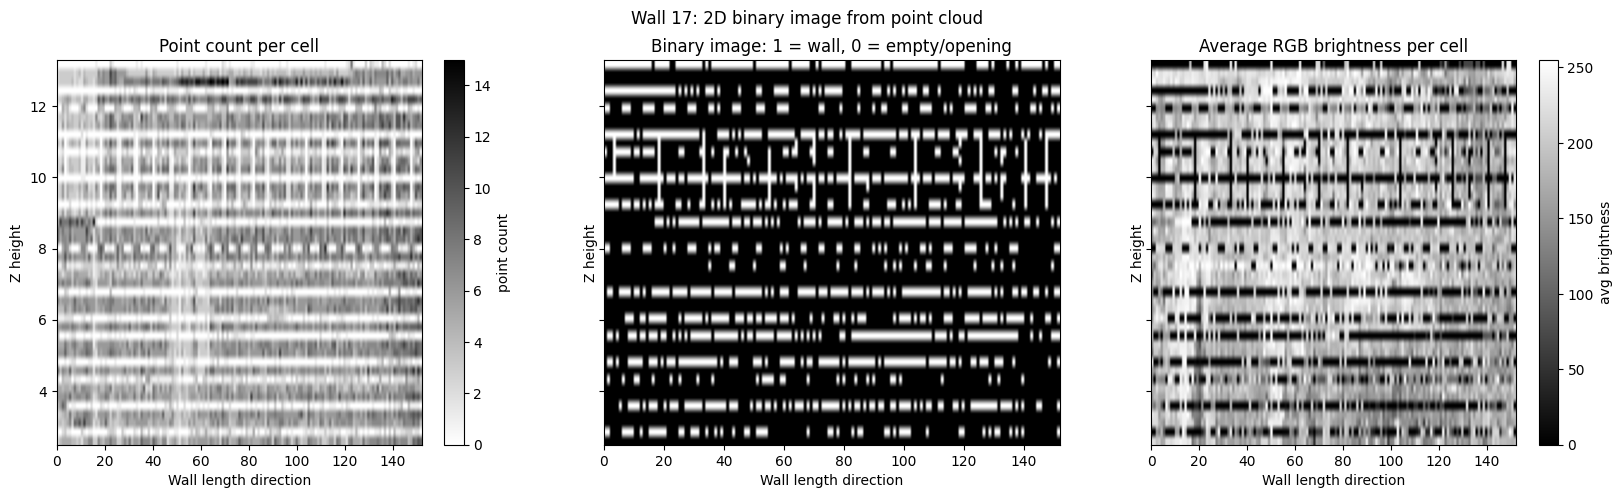

In [43]:
result = create_wall_binary_image(
    wall_output_dict,
    wall_id=17,
    length_bin_size=1.0,
    z_bin_size=0.25,
    count_threshold=1,
)

plot_wall_binary_image_result(
    result,
    wall_id=17,
    save_path="wall_17_binary_image.png",
)

In [25]:
import pandas as pd
import numpy as np
import open3d as o3d
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pickle
import alphashape
from shapely.geometry import Point, LineString, Polygon
import torch
from wall_seg_util import *
from io import BytesIO
from PIL import Image
from scipy.stats import mode
import json

In [15]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt

def extract_bbox_minmax(points_xyz, points_rgb):
    geometries = []
    bbox_minmax = []

    for i, pts in enumerate(points_xyz):
        pts = np.asarray(pts)
        rgb = np.asarray(points_rgb[i])  # <-- use i-th color array

        # Sanity checks
        if pts.ndim != 2 or pts.shape[1] != 3:
            raise ValueError(f"points_xyz[{i}] must be (N,3), got {pts.shape}")
        if rgb.ndim != 2 or rgb.shape[1] != 3:
            raise ValueError(f"points_rgb[{i}] must be (N,3), got {rgb.shape}")
        if len(rgb) != len(pts):
            raise ValueError(f"Mismatch at {i}: {len(pts)} points vs {len(rgb)} colors")

        # Convert color to float in [0,1]
        if rgb.dtype != np.float64:
            rgb = rgb.astype(np.float64)
        if rgb.max() > 1.0:
            rgb = rgb / 255.0

        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts.astype(np.float64))
        pcd.colors = o3d.utility.Vector3dVector(rgb)

        geometries.append(pcd)

        bbox = pcd.get_axis_aligned_bounding_box()
        bbox.color = (1, 0, 0)
        bbox_minmax.append([bbox.min_bound, bbox.max_bound])
        geometries.append(bbox)

    o3d.visualization.draw_geometries(geometries)
    return bbox_minmax



In [26]:
import pickle
with open("../points_zrgb.pkl", "rb") as f:
    points_zrgb = pickle.load(f)
points_xyz = [arr[:, :3] for arr in points_zrgb]
points_rgb = [arr[:, 3:] for arr in points_zrgb]

In [17]:
bbox = extract_bbox_minmax(points_xyz, points_rgb)

In [27]:
with open("../rotated_edge.pkl", "rb") as f:
    rotated_edge = pickle.load(f)
with open("../wall_bbox_edge.pkl", "rb") as f:
    wall_bbox_edge = pickle.load(f)
with open("../rotated_with_rgb.pkl", "rb") as f:
    rotated_with_rgb = pickle.load(f)

In [23]:
import numpy as np
import open3d as o3d

def bbox_corners_to_lineset(corners8, color=(1, 0, 0)):
    """
    corners8: (8,3) array of bbox corners.
    Assumes the first 4 corners are one face and last 4 corners are the opposite face
    in corresponding order (0-4,1-5,2-6,3-7).
    """
    corners8 = np.asarray(corners8, dtype=np.float64)
    if corners8.shape != (8, 3):
        raise ValueError(f"Expected corners shape (8,3), got {corners8.shape}")

    # 12 edges of a box
    lines = np.array([
        [0, 1], [1, 2], [2, 3], [3, 0],   # bottom face
        [4, 5], [5, 6], [6, 7], [7, 4],   # top face
        [0, 4], [1, 5], [2, 6], [3, 7],   # vertical edges
    ], dtype=np.int32)

    ls = o3d.geometry.LineSet(
        points=o3d.utility.Vector3dVector(corners8),
        lines=o3d.utility.Vector2iVector(lines),
    )
    ls.colors = o3d.utility.Vector3dVector(np.tile(np.array(color, dtype=np.float64), (len(lines), 1)))
    return ls

def visualize_points_and_bboxes(rotated_with_rgb, wall_bbox_edge, bbox_color=(1,0,0)):
    geometries = []

    # Add point clouds
    for i, arr in enumerate(rotated_with_rgb):
        arr = np.asarray(arr)
        xyz = arr[:, :3].astype(np.float64)

        rgb = arr[:, 3:6].astype(np.float64)
        if rgb.max() > 1.0:   # likely 0-255
            rgb /= 255.0

        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(xyz)
        pcd.colors = o3d.utility.Vector3dVector(rgb)
        geometries.append(pcd)

    # Add bbox edges
    for i, corners8 in enumerate(wall_bbox_edge):
        # your example shows wall_bbox_edge is like [[array(...), array(...), ...]]
        # so if wall_bbox_edge is nested, flatten it:
        if isinstance(corners8, list):
            for c in corners8:
                geometries.append(bbox_corners_to_lineset(c, color=bbox_color))
        else:
            geometries.append(bbox_corners_to_lineset(corners8, color=bbox_color))

    o3d.visualization.draw_geometries(geometries)

# call it
visualize_points_and_bboxes(rotated_with_rgb, wall_bbox_edge, bbox_color=(1, 0, 0))


In [32]:
def extract_bbox_minmax(points_xyz, points_rgb):
    geometries = []
    bbox_minmax = []

    for i, pts in enumerate(points_xyz):
        pts = np.asarray(pts, dtype=np.float64)
        rgb = np.asarray(points_rgb[i], dtype=np.float64)

        if rgb.max() > 1.0:
            rgb /= 255.0

        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)
        pcd.colors = o3d.utility.Vector3dVector(rgb)
        geometries.append(pcd)

        bbox = pcd.get_axis_aligned_bounding_box()
        bbox.color = (0, 1, 0)   # green for this bbox
        bbox_minmax.append([bbox.min_bound, bbox.max_bound])
        geometries.append(bbox)

    return bbox_minmax, geometries

def visualize_points_and_bboxes(rotated_with_rgb, wall_bbox_edge, bbox_color=(1,0,0)):
    geometries = []

    # point clouds
    for arr in rotated_with_rgb:
        arr = np.asarray(arr)
        xyz = arr[:, :3].astype(np.float64)
        rgb = arr[:, 3:6].astype(np.float64)
        if rgb.max() > 1.0:
            rgb /= 255.0

        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(xyz)
        pcd.colors = o3d.utility.Vector3dVector(rgb)
        geometries.append(pcd)

    # bbox edges
    for item in wall_bbox_edge:
        if isinstance(item, list):
            for c in item:
                geometries.append(bbox_corners_to_lineset(c, bbox_color))
        else:
            geometries.append(bbox_corners_to_lineset(item, bbox_color))

    return geometries


def pcd_from_csv_first6(csv_path, delimiter=",", skip_header=0):
    """
    CSV rows: x,y,z,r,g,b in first 6 columns.
    r,g,b can be 0-255 or 0-1.
    """
    data = np.loadtxt(csv_path, delimiter=delimiter, skiprows=skip_header)
    data = np.asarray(data)

    if data.ndim == 1:
        data = data[None, :]  # single row -> (1, N)

    if data.shape[1] < 6:
        raise ValueError(f"CSV must have at least 6 columns, got {data.shape[1]}")

    xyz = data[:, :3].astype(np.float64)
    rgb = data[:, 3:6].astype(np.float64)

    if rgb.max() > 1.0:
        rgb /= 255.0

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(xyz)
    pcd.colors = o3d.utility.Vector3dVector(rgb)
    return pcd



csv_pcd = pcd_from_csv_first6("WyomingStateFair_Laramie_Output.csv", skip_header=1) 

bbox_minmax, geom1 = extract_bbox_minmax(points_xyz, points_rgb)
geom2 = visualize_points_and_bboxes(rotated_with_rgb, wall_bbox_edge)

all_geometries = geom1 + geom2 + [csv_pcd]
o3d.visualization.draw_geometries(all_geometries)


In [3]:
# DBSCAN
EPS = 0.5
MIN_SAMPLES = 10

# Floor RANSAC
DIS_THR_F = 1 
RANSAC_N_F = 10 
NUM_ITER_F = 1000 
ALPHA_F = 2

# Ceiling RANSAC
DIS_THR_C = 1
RANSAC_N_C = 10 
NUM_ITER_C = 1000 
ALPHA_C = 1

PROJECTED_BINS = 300
RESIZE_WIDTH = 400
INT_THR = 20
SCORE_THR = 0.6
VERT_THR = 10
HORI_THR = 0.1
BUFFER_THR = 2

In [5]:
def plot_pred_point(df):
    # Extract xyzrgb columns (x, y, z, r, g, b)
    points = df[['x', 'y', 'z']].values
    colors = df[['r', 'g', 'b']].values
    colors_nor = df[['r', 'g', 'b']].values / 255.0  # Normalize RGB values to [0, 1]

    # Create Open3D point cloud
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    pcd.colors = o3d.utility.Vector3dVector(colors_nor)  # Assign RGB colors
    o3d.visualization.draw_geometries([pcd])

def cluster_floor_ceiling(df):
    # Extract xyzrgb columns (x, y, z, r, g, b)
    points = df[['x', 'y', 'z']].values
    colors = df[['r', 'g', 'b']].values
    colors_nor = df[['r', 'g', 'b']].values / 255.0  # Normalize RGB values to [0, 1]

    # Create Open3D point cloud
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    pcd.colors = o3d.utility.Vector3dVector(colors_nor)  # Assign RGB colors
    o3d.visualization.draw_geometries([pcd])
    # Optionally: Normalize the features for DBSCAN (x, y, z, r, g, b)
    features = np.hstack([points, colors_nor])  # Use x, y, z, r, g, b as features
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)

    # Perform DBSCAN clustering
    dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)  # Adjust parameters as needed
    cluster_num = dbscan.fit_predict(features_scaled)

    # Count the number of clusters (excluding noise points, labeled as -1)
    unique_num, counts = np.unique(cluster_num, return_counts=True)
    
    # Exclude noise (-1) & number of points < 10000 from cluster count
    cluster_dict = {label: np.hstack([points[cluster_num == label], colors[cluster_num == label]])for idx, label in enumerate(unique_num) if label != -1 and counts[idx] > 10000}
            
    return cluster_dict
    
def fit_ceiling_floor(df, distance_threshold, ransac_n, num_iterations, alpha_value):
    # Extract XYZ and RGB columns
    xyz = df[['x', 'y', 'z']].values  # Point coordinates
    rgb = df[['r', 'g', 'b']].values / 255.0  # Normalize RGB values (0-1)
    points = df[['x', 'y']].values
    # Create Open3D point cloud
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(xyz)
    pcd.colors = o3d.utility.Vector3dVector(rgb)  # Assign RGB colors

    # Apply RANSAC plane fitting
    plane_model, inliers = pcd.segment_plane(distance_threshold,  # Adjust threshold as needed
                                            ransac_n,
                                            num_iterations)

    # Extract plane parameters (ax + by + cz + d = 0)
    a, b, c, d = plane_model
    # print(f"Plane equation: {a}x + {b}y + {c}z + {d} = 0")

    # Extract inlier and outlier points
    inlier_cloud = pcd.select_by_index(inliers)  # Points belonging to the plane
    outlier_cloud = pcd.select_by_index(inliers, invert=True)  # Points not in the plane

    # Color the plane points (for visualization)
    inlier_cloud.paint_uniform_color([1.0, 0, 0])  # Red for plane
    outlier_cloud.paint_uniform_color([0, 0, 1.0])  # Blue for non-plane

    # Visualize the result
    o3d.visualization.draw_geometries([inlier_cloud, outlier_cloud], window_name="Plane Fitting")

    centroid = np.mean(np.asarray(inlier_cloud.points), axis=0)
    bbox = pcd.get_oriented_bounding_box()
    bbox.color = (0, 1, 0)  # Green box
    bbox_zmin = bbox.get_min_bound()[2]  # Compute the center
    bbox_zmax = bbox.get_max_bound()[2]
    o3d.visualization.draw_geometries([inlier_cloud, bbox])

    floor_points = np.asarray(pcd.points)[inliers]
    floor_points_2d = floor_points[:, :2]

    # Choose an appropriate alpha value. This is crucial and might require experimentation.
    # A smaller alpha will result in a tighter, more detailed (potentially fragmented) shape.
    # A larger alpha will approach the convex hull.
    
    # Create an alpha shape
    alpha_shape = alphashape.alphashape(floor_points_2d, alpha_value)
    if alpha_shape.geom_type == 'Polygon':
        boundary_coords = alpha_shape.exterior.coords
    elif alpha_shape.geom_type == 'MultiPolygon':
        boundary_coords = max(alpha_shape.geoms, key=lambda p: p.area).exterior.coords
    else:
        print("Alpha shape is not a Polygon or MultiPolygon.")
        boundary_coords = []

    # Plot if boundary was found
    if boundary_coords:
        boundary_array = np.array(boundary_coords)
        plt.figure()
        plt.scatter(points[:, 0], points[:, 1], s=10, label='Floor Points')
        plt.plot(boundary_array[:, 0], boundary_array[:, 1], 'r-', linewidth=2, label='Boundary')
        plt.scatter(boundary_array[:, 0], boundary_array[:, 1], s=1, color='red', label='Corner Points')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.title(f'Alpha Shape Boundary (alpha={alpha_value})')
        plt.legend()
        plt.grid(True)
        plt.axis('equal')
        plt.show()
    else:
        print("No valid boundary found.")

    
    line = LineString(boundary_coords)
    simplified = line.simplify(tolerance=0.8)  # tweak tolerance

    corner_coords = np.array(simplified.coords)

    extruded_coords = []
    for x, y in corner_coords:
        extruded_coords.append([x, y, bbox_zmin])
        extruded_coords.append([x, y, bbox_zmax])

    # Plot
    plt.scatter(points[:, 0], points[:, 1], s=1)
    plt.scatter(corner_coords[:, 0], corner_coords[:, 1], color="red", label="Corner Points")
    plt.title('Alpha Shape (Concave Hull)')
    plt.show()

    return bbox_zmin, bbox_zmax, extruded_coords

def points_between_level(bbox1, bbox2, xyzrgb):
    z_min_floor = bbox1[1]
    z_max_floor = bbox2[0]
    # Filter points between the floors
    filtered_points = xyzrgb[(xyzrgb[:, 2] > z_min_floor) & (xyzrgb[:, 2] < z_max_floor)]
    return filtered_points

def project_points_to_floor(filtered_points, bins):
    # Project to XY plane (ignore Z)
    xy_projected = filtered_points[:, :2]  # Keep only x, y
    
    # Create 2D histogram
    hist, x_edges, y_edges = np.histogram2d(xy_projected[:, 0], xy_projected[:, 1], bins=bins)

    # Plot histogram
    plt.figure(figsize=(10, 8))
    plt.imshow(hist.T, origin='lower', cmap='hot', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])
    plt.axis('off')

    # Save plot to a BytesIO object
    img_bytes = BytesIO()
    # Save figure without extra white space
    # img_path = 'bridger.png'
    # plt.savefig(img_path, bbox_inches='tight', pad_inches=0, dpi=300)
    plt.savefig(img_bytes, format='png', bbox_inches='tight', pad_inches=0, dpi=300)
    img_bytes.seek(0) 
    img = Image.open(img_bytes)
    img_array = np.array(img)
    bgr_arr = cv2.cvtColor(img_array, cv2.COLOR_RGBA2BGR)

    return xy_projected, x_edges, y_edges, bgr_arr

def point_axis_align(df, survey_basis):
    xyz = df[['x', 'y', 'z']].values
    rotated_xyz = xyz @ survey_basis.T

    # Convert back to DataFrame
    df_rotated = pd.DataFrame(rotated_xyz, columns=['x', 'y', 'z'])
    df_concate = pd.concat([df_rotated, df.iloc[:, 3:]], axis=1)

    return df_concate

def sorted_merged_floor_ceiling_plane(bbox_arr):
    sorted_data = sorted(bbox_arr, key=lambda x: x[1]) #sort by zmin

    # Create the result array
    plane_arr = []
    i = 0
    while i < len(sorted_data):
        current = sorted_data[i]

        if current[0] == 'ceiling' and i + 1 < len(sorted_data):
            next_item = sorted_data[i + 1]
            if next_item[0] == 'floor':
                # Merge ceiling and next floor
                z_min = min(current[1], next_item[1])
                z_max = max(current[2], next_item[2])
                plane_arr.append([z_min, z_max])
                i += 2  # Skip both
                continue

        # Otherwise, just add the current one
        plane_arr.append([current[1], current[2]])
        i += 1
    return plane_arr


def rotate_pt_back(mean, R, rotated_points):
    # Step 1: Shift rotated points back to the origin
    rotated_centered_points = rotated_points - mean

    # Step 2: Apply inverse rotation (transpose of R)
    original_points = (R.T @ rotated_centered_points.T).T

    # Step 3: Shift back to original mean
    original_points += mean
    return original_points


In [4]:
print("Torch:", torch.__version__)
print("Built with CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    print("Using GPU 0 ->", torch.cuda.get_device_name(0))
    torch.zeros(1, device="cuda")  # hard assert we can allocate on GPU
else:
    raise SystemExit("CUDA not available — running on CPU.")

Torch: 1.8.1+cu111
Built with CUDA: 11.1
CUDA available: True
GPU count: 1
Using GPU 0 -> NVIDIA GeForce RTX 4070 Laptop GPU


In [6]:
# Read the label file
with open("labels_clean2.txt", "r") as file:
    labels = [line.strip() for line in file.readlines()]  # Read and clean lines

# Create dictionary mapping labels to numeric values
label_dict = {label: idx for idx, label in enumerate(labels)}


# Load the CSV file
file_name = 'WyomingStateFair_Laramie_Output'
survey_basis = np.array([
    [-0.23829087279918065, 0.9711938323221605, 0.0],   # X
    [-0.9711938323221605, -0.23829087279918065, 0.0],  # Y
    [0.0, 0.0, 0.99999999999999978]                    # Z
    ]).T  # 3x3 rotation matrix

In [7]:
file_path = f"{file_name}.csv"  # Change this to your actual file path
df = pd.read_csv(file_path)

# prepare for JSON
points_lst, level_lst, wall_lst, floor_lst, ceiling_lst = [], [], [], [], []

In [13]:
### floor
print('Processing Floor......')
segment_floor_df = df[df['pred_label']==label_dict['Floor']].reset_index(drop=True)
# _, mean, R = point_axis_align_prev(segment_floor_df) 
align_axis_floor_df = point_axis_align(segment_floor_df, survey_basis)  ##
cluster_dict_floor = cluster_floor_ceiling(align_axis_floor_df) ##
# cluster_dict_floor = cluster_floor_ceiling(segment_df)
floor_ceiling_bboxz = [] ##
corner = []
level_id = 1
floor_id = 1
ceiling_id = 1


Processing Floor......


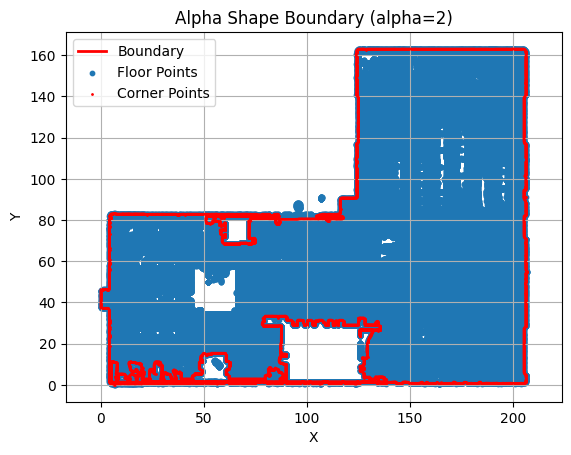

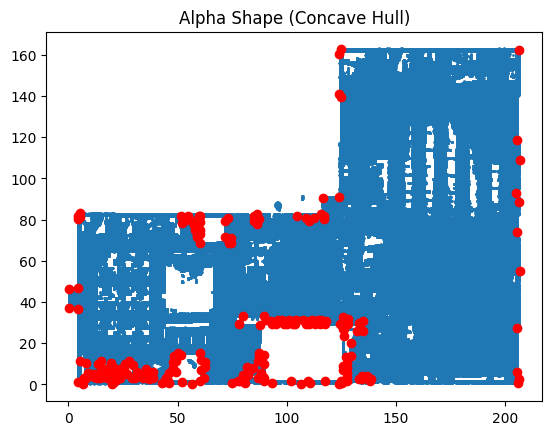

In [14]:
num=0
df_points_colors = pd.DataFrame(cluster_dict_floor[num], columns=['x', 'y', 'z', 'r', 'g', 'b'])
bbox_zmin, bbox_zmax, corner_xyz = fit_ceiling_floor(df_points_colors, DIS_THR_F, RANSAC_N_F, NUM_ITER_F, ALPHA_F)

In [16]:
floor_ceiling_bboxz.append(['floor', bbox_zmin, bbox_zmax])

rotated_corner = corner_xyz @ survey_basis 
corner.append(rotated_corner)

cluster_xyz_arr = cluster_dict_floor[num][:, :3]
cluster_rgb_arr = cluster_dict_floor[num][:, 3:]

# Apply the rotation function to each xyz row
rotated_xyz = cluster_xyz_arr @ survey_basis 
# Concatenate rotated xyz with original rgb
rotated_with_rgb = np.hstack((rotated_xyz, cluster_rgb_arr))

z_values = [pt[2] for pt in rotated_with_rgb] # Extract the third column (z)
mode_result = mode(z_values, keepdims=True)
mode_z = float(mode_result.mode[0])

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [10]:
floor_bboxz = [[-0.8758510267380262, 3.893814869570172], [11.839862577103396, 17.44238797510733]]
segment_wall_df = df[df['pred_label']==label_dict['Wall']].reset_index(drop=True)
align_axis_wall_df = point_axis_align(segment_wall_df, survey_basis) 
xyzrgb = align_axis_wall_df[['x', 'y', 'z', 'r', 'g', 'b']].values   

num_level = len(floor_bboxz)

# obtain line segmentation model checkpoints
checkpoint = torch.load('../checkpoints\checkpoint0024.pth', map_location='cuda')
model = load_line_segmentation_model(checkpoint)

wall_id = 1

Building LETR model... cuda


In [21]:
plane_arr = sorted_merged_floor_ceiling_plane(floor_ceiling_bboxz)

cpu cpu cpu cpu


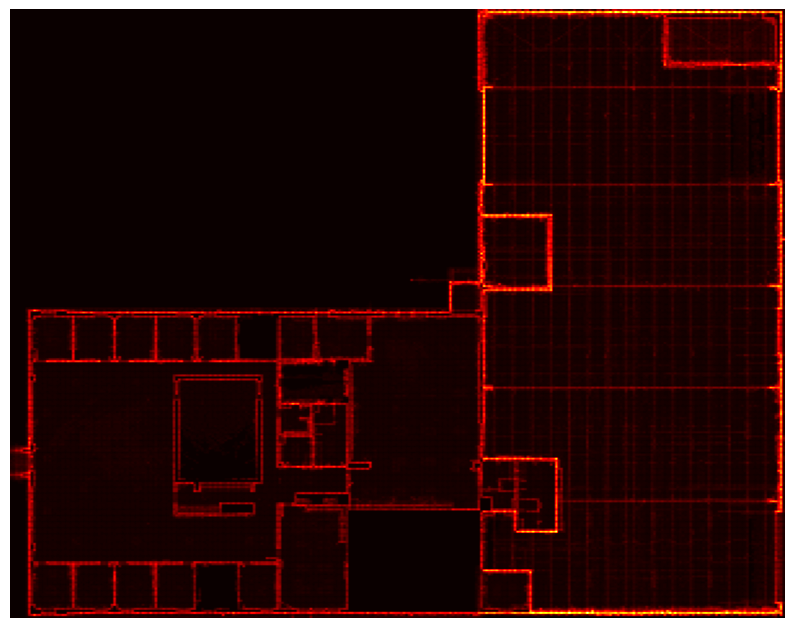

In [22]:
level = 0
if level == num_level - 1:    
    z_min_floor = plane_arr[-1][1]
    filtered_points = xyzrgb[(xyzrgb[:, 2] > z_min_floor)]
else:
    filtered_points = points_between_level(plane_arr[level], plane_arr[level+1], xyzrgb)

xy_projected, x_edges, y_edges, projected_img_arr = project_points_to_floor(filtered_points, PROJECTED_BINS)
inputs, orig_size, resize_ratio = img_process_model_input(projected_img_arr, RESIZE_WIDTH, INT_THR)
polyhv_arr = line_segmentation_inf(model, inputs, orig_size, projected_img_arr, resize_ratio, SCORE_THR, VERT_THR, HORI_THR, BUFFER_THR)
img_width, img_height = projected_img_arr.shape[1], projected_img_arr.shape[0]
ori_poly = [[pixel_to_xy(x, img_height-y, x_edges, y_edges, img_width, img_height, PROJECTED_BINS) for y, x in poly] for poly in polyhv_arr]
polygons = [Polygon(row) for row in ori_poly]

In [23]:
pts_in_poly = []
for poly in polygons:
    inside_points = [[point[0],point[1]] for point in xy_projected if poly.contains(Point(point))]
    if inside_points:
        pts_in_poly.append(inside_points)

In [ ]:

def find_zrgb(points, lookup):
    out = np.zeros((points.shape[0], 4)) * np.nan  # z,r,g,b columns

    for i, (x, y) in enumerate(points):
        out[i] = lookup.get((float(x), float(y)), [np.nan, np.nan, np.nan, np.nan])

    return np.hstack([points, out])


In [29]:
# filtered_points: [N, 6] → columns: x, y, z, r, g, b
lookup = {
    (float(x), float(y)): filtered_points[i, 2:6]
    for i, (x, y) in enumerate(filtered_points[:, :2])
}

In [32]:
points_zrgb = [find_zrgb(np.array(poly), lookup) for poly in pts_in_poly]

In [33]:
points_xyz = [arr[:, :3] for arr in points_zrgb]
points_rgb = [arr[:, 3:] for arr in points_zrgb]
bbox_minmax = extract_bbox_minmax(points_xyz)
edge_points = convert_to_edge_points(bbox_minmax)
# rotated_edge_prev = [[rotate_pt_back(mean, R, pt) for pt in pts] for pts in edge_points]
rotated_edge = [pts @ survey_basis for pts in edge_points]

wall_bbox_edge.append(rotated_edge)

rotated_wall_xyz = [pts @ survey_basis for pts in points_xyz]
rotated_with_rgb = [np.hstack((xyz, rgb)) for xyz, rgb in zip(rotated_wall_xyz, points_rgb)]

In [ ]:
import numpy as np
from scipy.spatial import ConvexHull

def estimate_yaw_minrect(xyz, step_deg=0.02):
    hull_pts = xyz[ConvexHull(xyz[:, :2]).vertices, :2]

    angles = np.deg2rad(np.arange(0.0, 90.0, step_deg))
    c, s = np.cos(angles), np.sin(angles)
   
    R = np.stack([np.stack([c, -s], -1), np.stack([s, c], -1)], -2)
    proj = hull_pts @ R.transpose(0, 2, 1)          # (A, N, 2)

    extent = proj.max(1) - proj.min(1)              # (A, 2)
    areas = extent[:, 0] * extent[:, 1]
    return np.rad2deg(angles[np.argmin(areas)])

In [25]:
def yaw_matrix(deg):
    a = np.deg2rad(deg)
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, -s, 0.],
                     [s,  c, 0.],
                     [0., 0., 1.]])

def point_axis_align(df, survey_basis=None):
    xyz = df[['x', 'y', 'z']].to_numpy()

    if survey_basis is not None:
        R = survey_basis
    else:
        R = yaw_matrix(estimate_yaw_minrect(xyz))
        print("Rotation matrix:\n", R)
    rotated = xyz @ R.T

    df_rot = pd.DataFrame(rotated, columns=['x', 'y', 'z'], index=df.index)
    return pd.concat([df_rot, df.iloc[:, 3:]], axis=1)

In [37]:
%pip install pye57

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: C:\Users\cwei\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import pandas as pd
import pye57

def e57_to_df(path, scan_index=None, transform=True):
    e57 = pye57.E57(path)
    idxs = range(e57.scan_count) if scan_index is None else [scan_index]

    frames = []
    for i in idxs:
        raw = e57.read_scan_raw(i, ignore_unsupported_fields=True)  
        xyz = np.column_stack([raw['cartesianX'],
                               raw['cartesianY'],
                               raw['cartesianZ']]).astype(np.float64)

        if 'cartesianInvalidState' in raw:
            keep = np.asarray(raw['cartesianInvalidState']) == 0
        else:
            keep = np.isfinite(xyz).all(axis=1)

        if transform:
            hdr = e57.get_header(i)
            xyz = xyz @ hdr.rotation_matrix.T + hdr.translation

        cols = {'x': xyz[keep, 0], 'y': xyz[keep, 1], 'z': xyz[keep, 2]}
        for src, dst in [('intensity', 'intensity'),
                         ('colorRed', 'r'), ('colorGreen', 'g'), ('colorBlue', 'b')]:
            if src in raw:
                cols[dst] = np.asarray(raw[src])[keep]

        sub = pd.DataFrame(cols)
        sub['scan'] = i
        frames.append(sub)

    return pd.concat(frames, ignore_index=True)


df = e57_to_df("LaramieCM.e57")
xyz = df[['x', 'y', 'z']].to_numpy()

In [64]:
import pandas as pd

# Read the label file
with open("src\labels_clean2.txt", "r") as file:
    labels = [line.strip() for line in file.readlines()]  # Read and clean lines

# Create dictionary mapping labels to numeric values
label_dict = {label: idx for idx, label in enumerate(labels)}

# file_path = "inference_prediction_laramie.csv" # Change this to your actual file path
# df = pd.read_csv(file_path)

# prepare for JSON
points_lst, level_lst, wall_lst, floor_lst, ceiling_lst = [], [], [], [], []

### floor
print('Processing Floor......')
# segment_floor_df = df[df['pred_label']==label_dict['Floor']].reset_index(drop=True)
align_axis_floor_df = point_axis_align(df)  

Processing Floor......
Rotation matrix:
 [[ 0.97476119 -0.22325012  0.        ]
 [ 0.22325012  0.97476119  0.        ]
 [ 0.          0.          1.        ]]
